Este documento carga el experimento 3rd_test con las clasificaciones de vida util (normal, inmminent Failure) y evalua los modelos entrenados usando el notebook `TF_entenamiento_agregados_v3.ipynb`

# Tabla de resultados 


| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| XGBoost      | 0.31         |  0.24        |   0.09       |
| CNN          | 0.41         |  0.28        |   0.31       |
| RNN          | 0.41         |  0.19        |   0.25       |
| LSTM         | 0.35         |  0.15        |   0.20       |
| DNN          | 0.43         |  0.28        |   0.30       |


## Resultados de Entrenamiento

<div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center;">

  <div style="text-align: center;">
    <h4>XGBoost</h4>
    <img src="artefactos/artefactos_test_v4/matriz_confusion_xgboost_3rd_test.png" width="800">
  </div>

  <div style="text-align: center;">
    <h4>CNN</h4>
    <img src="artefactos/artefactos_test_v4/matriz_confusion_cnn_3rd_test.png" width="800">
  </div>

  <div style="text-align: center;">
    <h4>RNN</h4>
    <img src="artefactos/artefactos_test_v4/matriz_confusion_rnn_3rd_test.png" width="800">
  </div>

  <div style="text-align: center;">
    <h4>LSTM</h4>
    <img src="artefactos/artefactos_test_v4/matriz_confusion_lstm_3rd_test.png" width="800">
  </div>

  <div style="text-align: center;">
    <h4>DNN</h4>
    <img src="artefactos/artefactos_test_v4/matriz_confusion_dnn_3rd_test.png" width="800">
  </div>

</div>


# Declaración de librerías


In [1]:
# en este caso solo se evaluaran los modelos no de usara GPU
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf

2026-05-08 19:37:03.787365: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 19:37:03.787603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 19:37:03.834968: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 19:37:03.937725: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-08 19:37:05.207265: W tensorflow/compiler/tf2

In [2]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)
        self.true_positives.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh, axis=0))
        self.false_positives.assign_add(tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0))
        self.false_negatives.assign_add(tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0))

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

    # estos dos métodos permiten serializar/deserializar correctamente
    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [4]:
# Carpeta de artefactos, modelos y resultados
dir_in_artifacts = "artefactos/artefactos_train_v4"


dir_out_artifacts = "artefactos/artefactos_test_v4"

# crear carpeta si no existe
import os
os.makedirs(dir_out_artifacts, exist_ok=True)

# Limpieza y armado de tensores

In [23]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test_reetiquetado.csv")

In [20]:
np.unique(df["vida_util"], return_counts=True)

(array(['Inminent failure', 'Normal'], dtype=object), array([  916, 24380]))

In [21]:
df.head(5)

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,vida_util
0,2004.03.04.09.27.46,Canal 1,0.5580,-0.004716,0.079770,1.116,6.995122,0.006341,0.079630,0.000556,...,10.656567,0.030942,1.292610,0.000016,0.000052,1.143656,2933.661089,3565.675004,0.112713,Normal
1,2004.03.04.09.27.46,Canal 2,0.4820,-0.003918,0.096704,0.964,4.984260,0.009336,0.096625,0.000675,...,8.382372,0.151494,0.776298,0.000137,0.000068,1.453733,3830.510054,4623.276175,0.136705,Normal
2,2004.03.04.09.27.46,Canal 3,0.3355,-0.005150,0.066391,0.671,5.053391,0.004381,0.066191,0.000463,...,8.308634,0.083539,0.592235,0.000024,0.000011,1.445029,3637.263293,4513.738117,0.093750,Normal
3,2004.03.04.09.27.46,Canal 4,0.2785,-0.004329,0.055493,0.557,5.018651,0.003061,0.055324,0.000387,...,6.996599,0.038759,0.560056,0.000007,0.000005,1.451498,3043.232594,3621.066994,0.078359,Normal
4,2004.03.04.09.32.46,Canal 1,0.4760,-0.005097,0.078677,0.952,6.050087,0.006164,0.078511,0.000549,...,9.700500,-0.013894,1.157367,-0.000007,0.000044,1.276069,3127.918633,3753.023246,0.111149,Normal


In [25]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
# df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
# features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])
# retirar columnas de frecuencia usadas en otras versiones
features = df.columns.drop(["archivo", "canal", "vida_util", "mean_frequency", "rms_frequency", "envelope_rms"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    # y.append(bloque["salud_miltos"].iloc[0])
    y.append(bloque["vida_util"].iloc[0])


X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(6324, 4, 21)
(6324,)


In [26]:
np.unique(y)

array(['Inminent failure', 'Normal'], dtype='<U16')

In [27]:
#codificacion de clases 
import numpy as np

# definir el mapeo manualmente
classes = np.array(['Early', 'Inminent failure', 'Normal', 'Suspect'])
mapeo = {
    'Early':             0,
    'Inminent failure':  1,
    'Normal':            2,
    'Suspect':           3,
}

# aplicar el mapeo
y = np.array([mapeo[etiqueta] for etiqueta in y])

num_classes = len(mapeo)

# decodificador inverso para recuperar los nombres originales
mapeo_inverso = {v: k for k, v in mapeo.items()}

# verificar asignacion
for clase, codigo in mapeo.items():
    print(f"{codigo} → {clase}")




0 → Early
1 → Inminent failure
2 → Normal
3 → Suspect


In [28]:
# escalado de features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(X.shape)

# division en train y test
from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

# en esta ocasion se tomara todo el conjunto de datos para evaluacion
X_test = X
y_test = y

In [29]:
# X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_test.shape, y_test.shape


((6324, 4, 21), (6324,))

In [30]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. 
# Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1). 

# Ademas se repetiran 4 de los canales porque este conjunto de datos tiene menos canales 
X_test_8ch = np.concatenate([X_test, X_test], axis=1)  # (n, 8, 21)


# aplanar a 2D
X_train_2d = X_test_8ch.reshape(X_test_8ch.shape[0], -1) # (n, 168)
X_test_2d = X_test_8ch.reshape(X_test_8ch.shape[0], -1)  # (n, 168)

print(X_train_2d.shape)  # (1724, 168)
print(X_test_2d.shape)   # (431, 168)

(6324, 168)
(6324, 168)


# Arbol de clasificación

Este modelo no estaba previsto realizar entremientos, sin embargo, es ampliamente conocido por su excelente desempleño con datos tabulares por que se decidió realizar un entrenamiento para observar los resultados y comparar.

In [31]:
# # Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
# X_train_2d = X_train.reshape(X_train.shape[0], -1)
# X_test_2d  = X_test.reshape(X_test.shape[0], -1)

# print(X_train_2d.shape)  # (1724, 168)
# print(X_test_2d.shape)   # (431, 168)

## Evaluación

In [32]:
# Usar modelo recien entrenado para predecir en el conjunto de test
# best_model = grid.best_estimator_

# y_pred = best_model.predict(X_test_2d)


# cargar modelo anterior entrenado como sklearn
import xgboost as xgb

# cargar el modelo
best_model = xgb.XGBClassifier()
best_model.load_model(f"{dir_in_artifacts}/xgboost_mejorado.json")
y_pred = best_model.predict(X_test_2d)



In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3],        # forzar las 4 clases
    target_names=classes,
    zero_division=0              # evita error si alguna clase tiene 0 predicciones
))

Accuracy: 0.05913978494623656
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.06      0.99      0.12       374
          Normal       1.00      0.00      0.00      5950
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.06      6324
       macro avg       0.27      0.25      0.03      6324
    weighted avg       0.94      0.06      0.01      6324



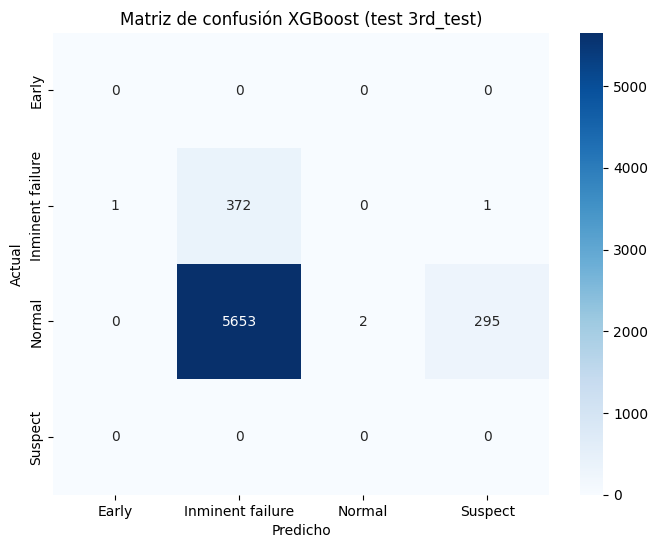

In [34]:

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            # xticklabels=le.classes_,
            xticklabels=classes,
            # yticklabels=le.classes_,
            yticklabels=classes,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost (test 3rd_test)")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_out_artifacts}/matriz_confusion_xgboost_3rd_test.png", dpi=300, bbox_inches='tight')
plt.show()

# MK - CNN


## Evaluacion

In [35]:
# cargar modelo guardado para evaluar en test
import tensorflow as tf


best_model = tf.keras.models.load_model(
    f"{dir_in_artifacts}/cnn_mejorada.h5",
    custom_objects={"F1MacroScore": F1MacroScore},
    compile=False  # evita el problema de deserialización
)

# recompilar manualmente
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
)

# verificar que cargó bien
best_model.summary()

2026-05-08 19:43:48.887046: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 8, 128)            8192      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 4, 128)            0         
 g1D)                                                            
                                                                 
 conv1d_3 (Conv1D)           (None, 4, 64)             16448     
                                                                 
 flatten_1 (Flatten)         (None, 256)               0         
                                                                 
 dense_26 (Dense)            (None, 32)                8224      
                                                                 
 dropout_8 (Dropout)         (None, 32)                0         
                                                      

In [36]:
import tensorflow as tf

print("Dispositivos:", tf.config.list_physical_devices())
print("GPU:", tf.config.list_physical_devices('GPU'))

Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU: []


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_model.predict(X_test_8ch)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3],        # forzar las 4 clases
    target_names=classes,
    zero_division=0              # evita error si alguna clase tiene 0 predicciones
))

198/198 [==============================] - 1s 2ms/step
Accuracy: 0.8429791271347249
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.65      0.78      0.71       374
          Normal       0.99      0.85      0.91      5950
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.84      6324
       macro avg       0.41      0.41      0.41      6324
    weighted avg       0.97      0.84      0.90      6324



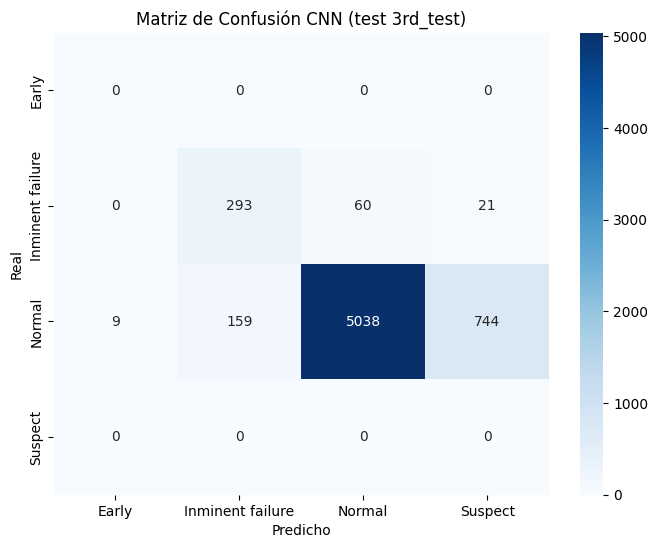

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN (test 3rd_test)")
plt.savefig(f"{dir_out_artifacts}/matriz_confusion_cnn_3rd_test.png", dpi=300, bbox_inches='tight')

plt.show()

# RNN


## Evaluación

In [39]:
# cargar modelo guardado para evaluar en test
import tensorflow as tf


best_model = tf.keras.models.load_model(
    f"{dir_in_artifacts}/rnn_mejorada.h5",
    custom_objects={"F1MacroScore": F1MacroScore},
    compile=False  # evita el problema de deserialización
)

# recompilar manualmente
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
)

# verificar que cargó bien
best_model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 8, 96)             11328     
                                                                 
 dropout_9 (Dropout)         (None, 8, 96)             0         
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 80)                14160     
                                                                 
 dense_28 (Dense)            (None, 64)                5184      
                                                                 
 dense_29 (Dense)            (None, 4)                 260       
                                                                 
Total params: 30932 (120.83 KB)
Trainable params: 30932 (120.83 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_model.predict(X_test_8ch)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

198/198 [==============================] - 1s 2ms/step
Accuracy: 0.5112270714737508
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.72      0.79      0.75       374
          Normal       0.99      0.49      0.66      5950
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.51      6324
       macro avg       0.43      0.32      0.35      6324
    weighted avg       0.98      0.51      0.67      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

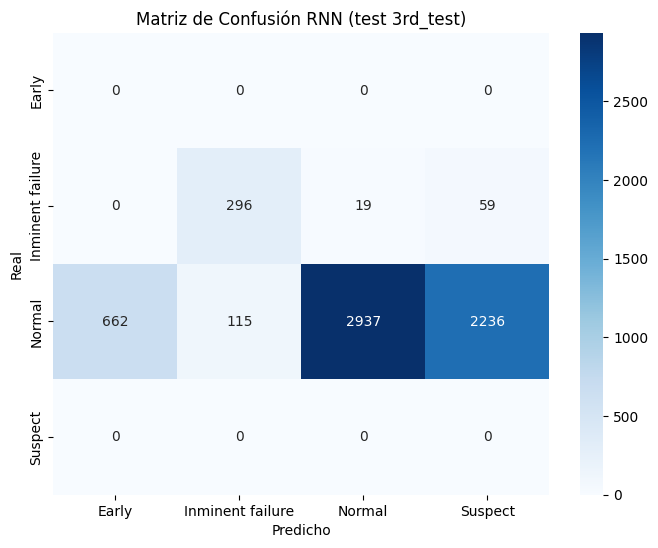

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN (test 3rd_test)")
plt.savefig(f"{dir_out_artifacts}/matriz_confusion_rnn_3rd_test.png", dpi=300, bbox_inches='tight')

plt.show()

# LSTM

## Evaluación

In [42]:
# cargar modelo guardado para evaluar en test
import tensorflow as tf


best_model = tf.keras.models.load_model(
    f"{dir_in_artifacts}/lstm_mejorada.h5",
    custom_objects={"F1MacroScore": F1MacroScore},
    compile=False  # evita el problema de deserialización
)

# recompilar manualmente
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
)

# verificar que cargó bien
best_model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 8, 32)             6912      
                                                                 
 dropout_10 (Dropout)        (None, 8, 32)             0         
                                                                 
 lstm_3 (LSTM)               (None, 80)                36160     
                                                                 
 dense_30 (Dense)            (None, 128)               10368     
                                                                 
 dense_31 (Dense)            (None, 4)                 516       
                                                                 
Total params: 53956 (210.77 KB)
Trainable params: 53956 (210.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_model.predict(X_test_8ch)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.2523719165085389
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.25      0.73      0.38       374
          Normal       1.00      0.22      0.36      5950
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.25      6324
       macro avg       0.31      0.24      0.19      6324
    weighted avg       0.96      0.25      0.36      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

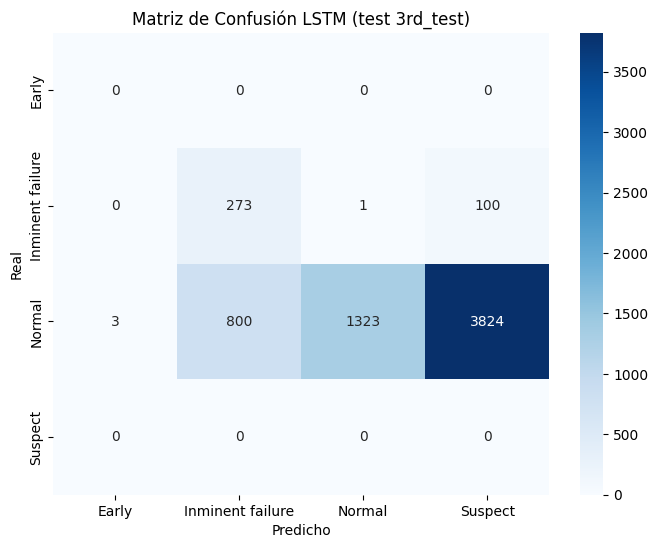

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM (test 3rd_test)")
plt.savefig(f"{dir_out_artifacts}/matriz_confusion_lstm_3rd_test.png", dpi=300, bbox_inches='tight')

plt.show()

# Deep Neural Network

## Evaluación

In [45]:
# cargar modelo guardado para evaluar en test
import tensorflow as tf


best_model = tf.keras.models.load_model(
    f"{dir_in_artifacts}/dnn_mejorada.h5",
    custom_objects={"F1MacroScore": F1MacroScore},
    compile=False  # evita el problema de deserialización
)

# recompilar manualmente
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
)

# verificar que cargó bien
best_model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 96)                16224     
                                                                 
 dense_33 (Dense)            (None, 64)                6208      
                                                                 
 dense_34 (Dense)            (None, 32)                2080      
                                                                 
 dropout_11 (Dropout)        (None, 32)                0         
                                                                 
 dense_35 (Dense)            (None, 4)                 132       
                                                                 
Total params: 24644 (96.27 KB)
Trainable params: 24644 (96.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_pred = best_model.predict(X_test_2d)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

198/198 [==============================] - 0s 1ms/step
Accuracy: 0.9240986717267552
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.91      0.77      0.83       374
          Normal       0.99      0.93      0.96      5950
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.92      6324
       macro avg       0.47      0.43      0.45      6324
    weighted avg       0.98      0.92      0.95      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

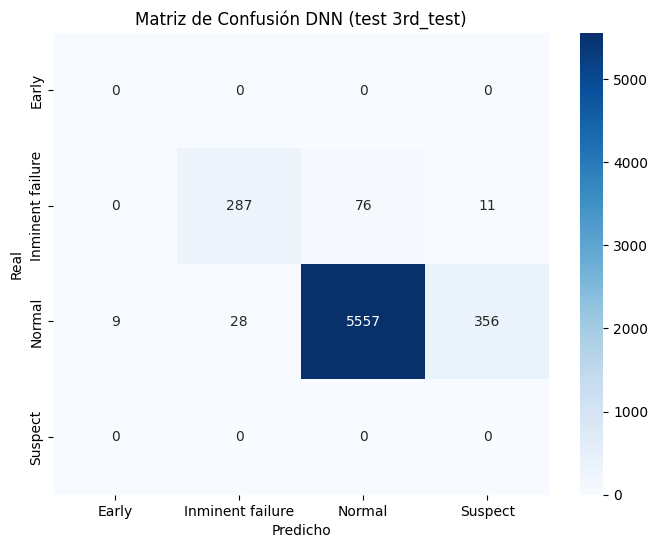

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN (test 3rd_test)")
plt.savefig(f"{dir_out_artifacts}/matriz_confusion_dnn_3rd_test.png", dpi=300, bbox_inches='tight')

plt.show()